In [1]:
import os, shutil
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchvision.models import resnet18, ResNet18_Weights, resnet34, ResNet34_Weights, resnet50, ResNet50_Weights, resnet101, ResNet101_Weights, resnet152, ResNet152_Weights

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score

from time import perf_counter

# Arquitecturas

## General

In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [3]:
def getImage(path):
    """This function reads an image from a path and applies the transformation."""
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0).cuda()

In [4]:
def train_net(net,dataset):
    memory_bank = []
    backbone = net.cuda()

    folder_path = Path(f'/home/jamor/redes/MVTec-AD/data/raw/{dataset}/train/good')
    total = sum(1 for _ in folder_path.iterdir())
    for pth in tqdm(folder_path.iterdir(), total=total, leave=False, desc=f"Extracting features"):
        # print(pth)
        with torch.no_grad():
            data = getImage(pth)
            features = backbone(data)
            # print(features.shape)
            memory_bank.append(features.cpu().detach())

    #print(f'Number of features in memory bank: {len(memory_bank)}')
    #print(f'Feature shape: {memory_bank[0].shape}')
    memory_bank = torch.cat(memory_bank,dim=0).cuda()
    #print(f'Memory bank shape: {memory_bank.shape}') # 784x391 = 306544
    selected_indices = np.random.choice(len(memory_bank), size=len(memory_bank)//10, replace=False)
    memory_bank = memory_bank[selected_indices]
    #print(f'New memory bank shape: {memory_bank.shape}')
    net.memory_bank[dataset] = memory_bank

In [5]:
def anomaly_map(net,dataset,data,test=True):
    """This function computes the anomaly map for a given feature and a memory bank."""
    memory_bank = net.memory_bank[dataset]
    backbone = net.cuda()
    with torch.no_grad():
        features = backbone(data)
        # print(features.shape)
    distances = torch.cdist(features, memory_bank, p=2.0)
    # print(distances.shape)
    dist_score, dist_score_idxs = torch.min(distances, dim=1) 
    # print(dist_score[:10], dist_score_idxs[:10])
    s_star = torch.max(dist_score)
    # print(s_star)
    segm_map = dist_score.view(1, 1, 28, 28) 
    # print(segm_map.shape)
    if test:
        # Upscale by bi-linaer interpolation to match the original input resolution
        segm_map = torch.nn.functional.interpolate(
            segm_map,
            size=(224, 224),
            mode='bilinear'
            )
    return segm_map, s_star

In [6]:
def train_good(net,dataset):
    global y_score_good
    y_score_good = []
    folder_path = Path(f'/home/jamor/redes/MVTec-AD/data/raw/{dataset}/train/good')
    total = sum(1 for _ in folder_path.iterdir())
    for pth in tqdm(folder_path.iterdir(), total=total, leave=False, desc=f"Computing best threshold"):
        data = getImage(pth)
        # print(data.shape)
        segm_map, s_star = anomaly_map(net,dataset, data,False)

        y_score_good.append(s_star.cpu().numpy())
        # break

    best_threshold = np.mean(y_score_good) + 3 * np.std(y_score_good)
    #print(f"Threshold: {best_threshold}")
    net.best_thresholds[dataset] = best_threshold

In [7]:
def test_net(net,dataset):
    y_score = []
    y_true = []
    path = f"/home/jamor/redes/MVTec-AD/data/raw/{dataset}/test"
    contents = os.listdir(path)
    best_threshold = net.best_thresholds[dataset]
    for classes in contents:
        folder_path_test = Path(f"{path}/{classes}")
        files = list(folder_path_test.iterdir()) 
        for pth in tqdm(files, leave=False,desc=f"Testing {classes}"):
            # print(pth)
            class_label = pth.parts[-2]
            # print(class_label)
            test_image = getImage(pth)
            segm_map, s_star = anomaly_map(net,dataset, test_image)

            y_score.append(s_star.cpu().numpy())
            y_true.append(0 if class_label=='good' else 1)  # 0 -> GOOD, 1 -> BAD
            # break
    net.f1_scores[dataset] = f1_score(y_true, y_score >= best_threshold)
    net.cm[dataset] = confusion_matrix(y_true, (y_score >= best_threshold).astype(int))
    net.y_score_good[dataset] = [score for score,true in zip(y_score, y_true) if true==0]
    net.y_score_bad[dataset] = [score for score,true in zip(y_score, y_true) if true==1]
    

In [8]:
def net_pipeline(net,dataset):
    t0 = perf_counter()
    train_net(net, dataset)
    train_good(net,dataset)
    t1 = perf_counter()
    net.training_times[dataset] = t1 - t0
    test_net(net, dataset)
    t2 = perf_counter()
    net.testing_times[dataset] = t2 - t1

In [9]:
def show_results(net,dataset):
    y_score_bad = net.y_score_bad[dataset]
    y_score_good = net.y_score_good[dataset]
    cm = net.cm[dataset]
    best_threshold = net.best_thresholds[dataset]
    fig, axes = plt.subplots(1, 3, figsize=(12,3))
    y_score_good = np.asarray(y_score_good).astype(float).ravel()
    y_score_bad = np.asarray(y_score_bad).astype(float).ravel()
    sns.histplot(y_score_good, bins=50, ax=axes[0],linewidth=0, color="steelblue")
    axes[0].axvline(best_threshold, color='red', linestyle='--')
    axes[0].set_title(f"Model: {net.name}")

    df_test = pd.DataFrame({
        "score":list(y_score_good) + list(y_score_bad),
        "label": ["Good"]*len(y_score_good) + ["Bad"]*len(y_score_bad)
    })

    sns.histplot(
        data=df_test,
        x="score",
        hue="label",
        bins=50,
        alpha=0.6,
        linewidth=0,
        ax=axes[1]
    )

    axes[1].axvline(net.best_thresholds[dataset], color='red', linestyle='--')
    axes[1].set_title(f"Dataset: {dataset}")

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        cbar=False,
        square=True,
        cbar_kws={"label": "Count"},
        xticklabels=["Good", "Bad"],
        yticklabels=["Good", "Bad"],
        ax=axes[2]
    )

    axes[2].set_title(f"F1 Score: {net.f1_scores[dataset]:.4f}")

    plt.tight_layout()
    plt.show()

In [10]:
def show_examples(net,dataset):
    path = f"/home/jamor/redes/MVTec-AD/data/raw/{dataset}/test"
    contents = os.listdir(path)
    best_threshold = net.best_thresholds[dataset]
    for classes in contents:
        folder_path_test = Path(f"{path}/{classes}")
        files = list(folder_path_test.iterdir()) 
        file = random.choice(files) 
        test_image = getImage(file)
        segm_map, s_star = anomaly_map(net,dataset, test_image)
        segm_map = segm_map.cpu().squeeze().numpy()
        y_score_image = s_star.cpu().numpy()
        fault_type = file.parts[-2]
        heat_map = segm_map
        segmentation = heat_map > best_threshold
        if fault_type == 'good':
            ground_truth = np.zeros_like(segmentation)
            iou = 100.0
        else:
            ground_truth = getImage(Path(str(file).replace("/test/","/ground_truth/").replace(".png", "_mask.png"))).squeeze().permute(1,2,0).cpu().numpy()
            and_map = segmentation * ground_truth[:,:,0]
            or_map = segmentation + ground_truth[:,:,0] - and_map
            iou = 100*(and_map).sum(axis=(0,1))/(or_map).sum(axis=(0,1))
        plt.figure(figsize=(12,3))
        plt.subplot(1,4,1)
        plt.imshow(test_image.squeeze().permute(1,2,0).cpu().numpy())
        plt.title(f'fault type: {fault_type}')

        plt.subplot(1,4,2)
        
        plt.imshow(heat_map) 
        plt.title(f'Anomaly score: {y_score_image:0.2f}/{best_threshold:0.2f}')
        
        

        plt.subplot(1,4,3)
        plt.imshow(segmentation, cmap='gray')  #
        plt.title(f'segmentation map')

        plt.subplot(1,4,4)
        #plt.hist(heat_map.flatten(), bins=50)
        plt.imshow(ground_truth, cmap='gray')
        plt.title(f'Ground Truth, IoU: {iou:0.2f}%')

        
        plt.show()

## Resnet 18

In [11]:
class resnet18_feature_extractor(torch.nn.Module):
    def __init__(self):
        """This class extracts the feature maps from a pretrained Resnet model."""
        super(resnet18_feature_extractor, self).__init__()
        self.name = "resnet18"
        self.model = resnet18(weights=ResNet18_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        
        # Hook to extract feature maps
        def hook(module, input, output) -> None:
            """This hook saves the extracted feature map on self.featured."""
            self.features.append(output)

        self.model.layer2[-1].register_forward_hook(hook)            
        self.model.layer3[-1].register_forward_hook(hook) 
        self.memory_bank = {}
        self.best_thresholds = {}

        self.cm = {}
        self.y_score_good = {}
        self.y_score_bad = {}

        self.f1_scores = {}
        self.cm = {}
        self.training_times = {}
        self.testing_times = {}

    def forward(self, input):

        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride=1)
        fmap_size = self.features[0].shape[-2]         # Feature map sizes h, w
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)            # Merge the resized feature maps
        patch = patch.reshape(patch.shape[1], -1).T   # Craete a column tensor

        return patch

## ResNet50

In [12]:
class resnet50_feature_extractor(torch.nn.Module):
    def __init__(self):
        """This class extracts the feature maps from a pretrained Resnet model."""
        super(resnet50_feature_extractor, self).__init__()
        self.name = "resnet50"
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        
        # Hook to extract feature maps
        def hook(module, input, output) -> None:
            """This hook saves the extracted feature map on self.featured."""
            self.features.append(output)

        self.model.layer2[-1].register_forward_hook(hook)            
        self.model.layer3[-1].register_forward_hook(hook) 
        self.memory_bank = {}
        self.best_thresholds = {}

        self.cm = {}
        self.y_score_good = {}
        self.y_score_bad = {}

        self.f1_scores = {}
        self.cm = {}
        self.training_times = {}
        self.testing_times = {}

    def forward(self, input):

        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride=1)
        fmap_size = self.features[0].shape[-2]         # Feature map sizes h, w
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)            # Merge the resized feature maps
        patch = patch.reshape(patch.shape[1], -1).T   # Craete a column tensor

        return patch

# Resultados

In [ ]:
path = "/home/jamor/redes/MVTec-AD/data/raw/"
datasets = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))] # solo directorios no archivos
datasets = datasets[:2] # para debugear mas rapido
tot = len(datasets)

nets = [resnet18_feature_extractor(),resnet50_feature_extractor()]
N = len(nets)
for i, net in enumerate(nets):
    print(f"Processing net ({i+1}/{N}): {net.name}")
    print("")
    for j, dataset in enumerate(datasets[:2]):
        print(f"    Processing dataset ({j+1}/{tot}): {dataset}")
        net_pipeline(net, dataset)
    

Processing dataset (1/2): hazelnut
Processing net (1/2): resnet18


Extracting features:   0%|          | 0/391 [00:00<?, ?it/s]

Computing best threshold:   0%|          | 0/391 [00:00<?, ?it/s]

Testing crack:   0%|          | 0/18 [00:00<?, ?it/s]

Testing print:   0%|          | 0/17 [00:00<?, ?it/s]

...

Testing pill_type:   0%|          | 0/9 [00:00<?, ?it/s]

Testing faulty_imprint:   0%|          | 0/19 [00:00<?, ?it/s]

Testing color:   0%|          | 0/25 [00:00<?, ?it/s]

Testing good:   0%|          | 0/26 [00:00<?, ?it/s]

Testing scratch:   0%|          | 0/24 [00:00<?, ?it/s]

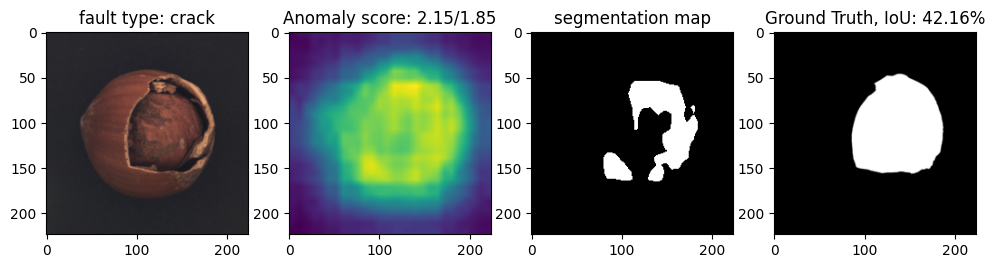

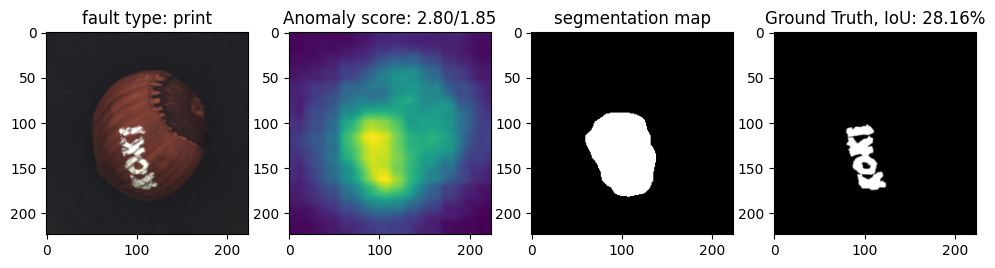

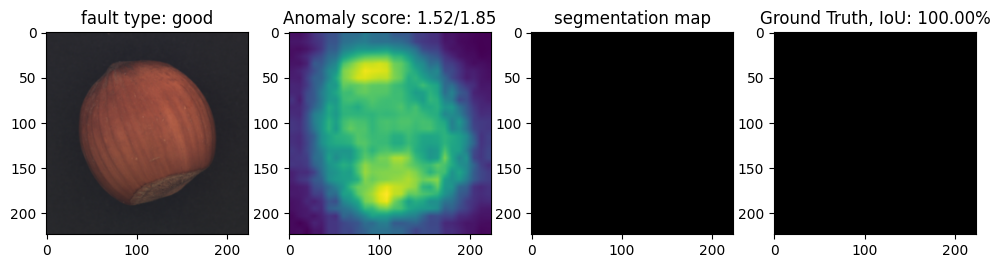

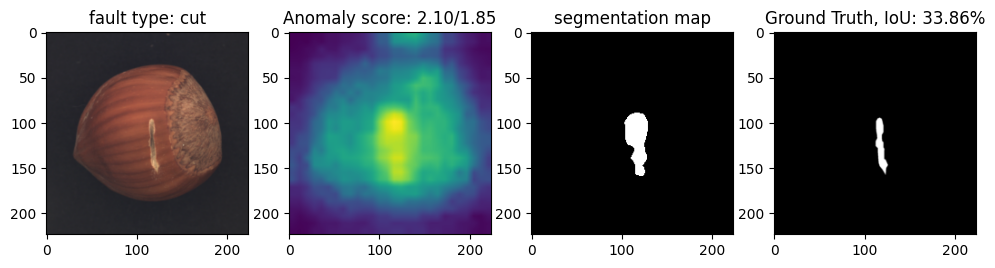

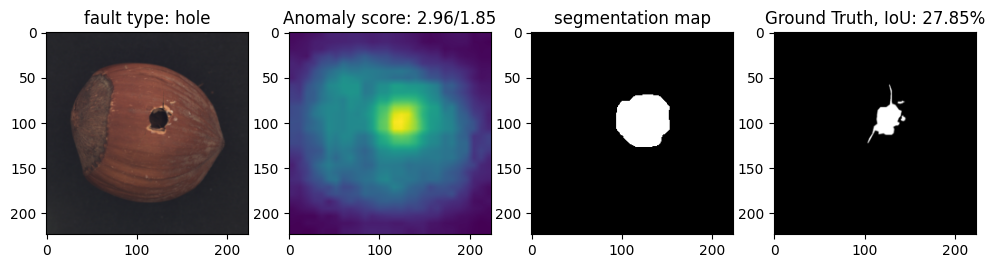

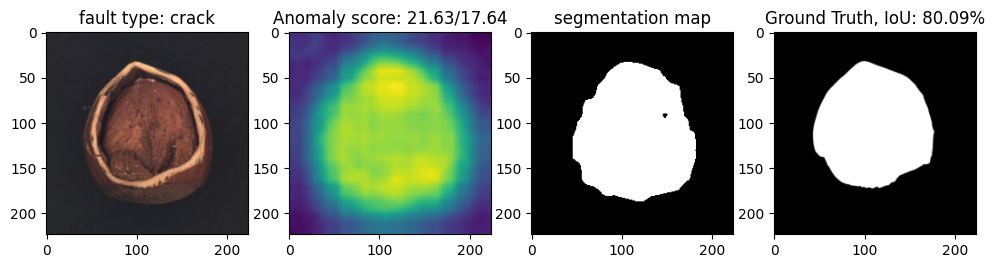

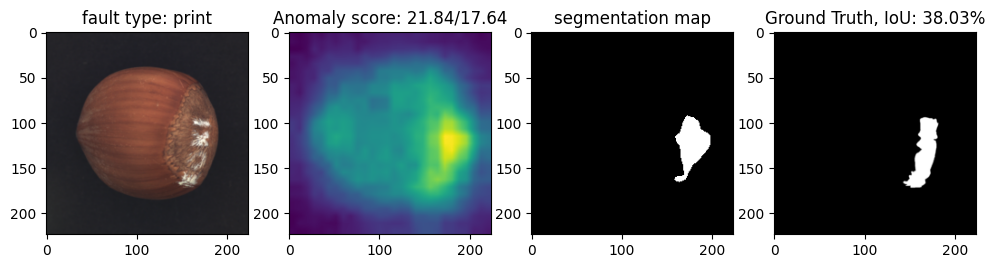

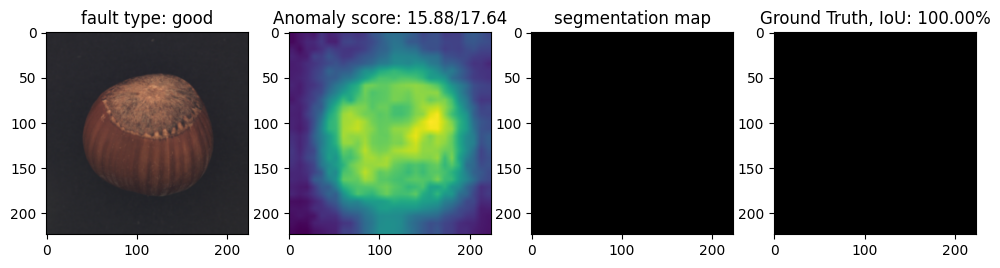

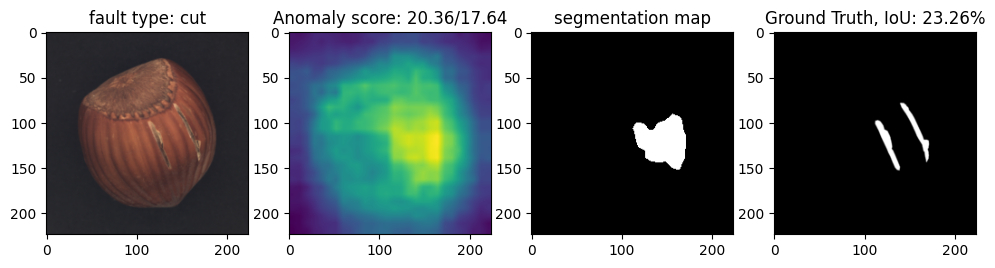

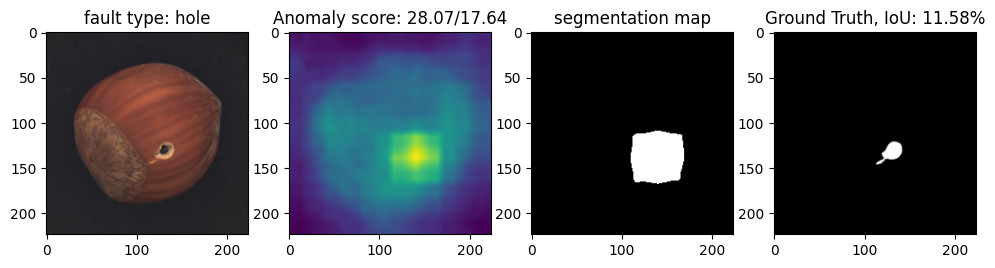

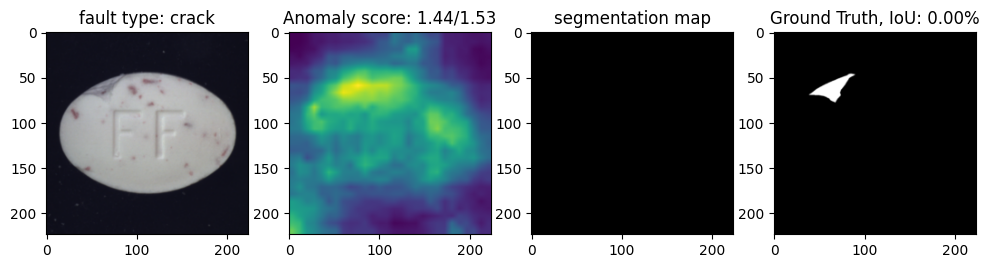

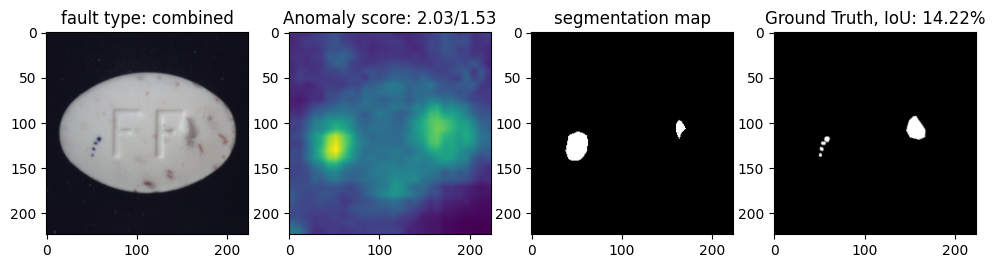

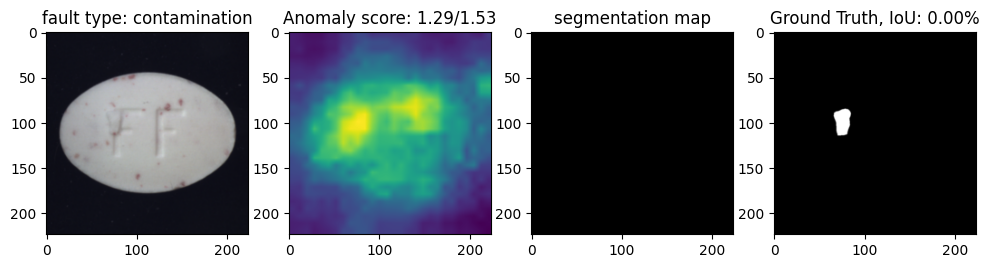

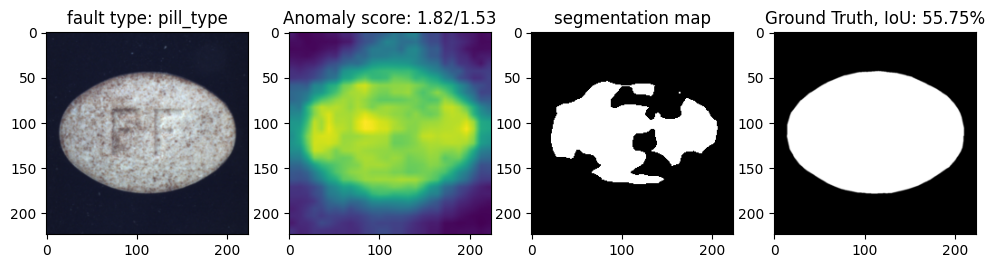

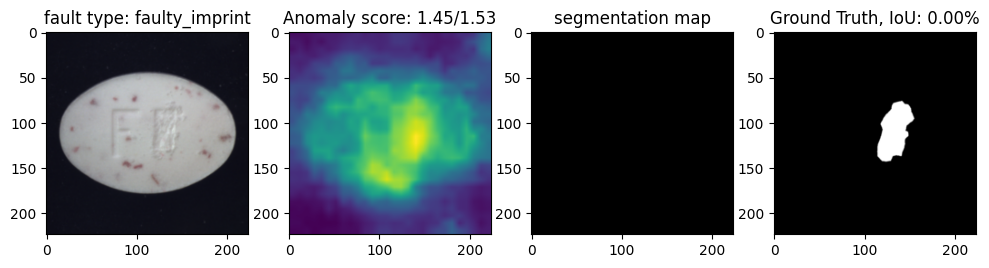

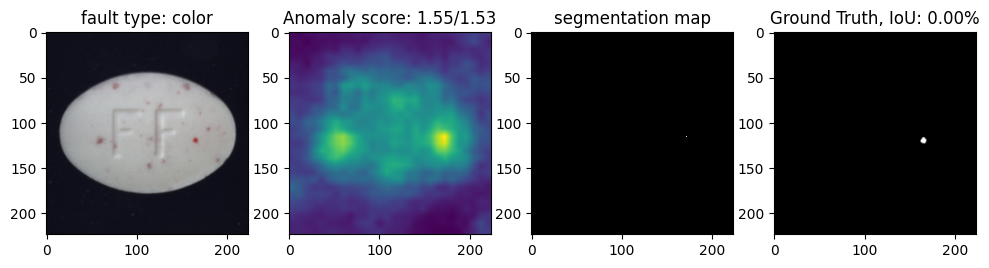

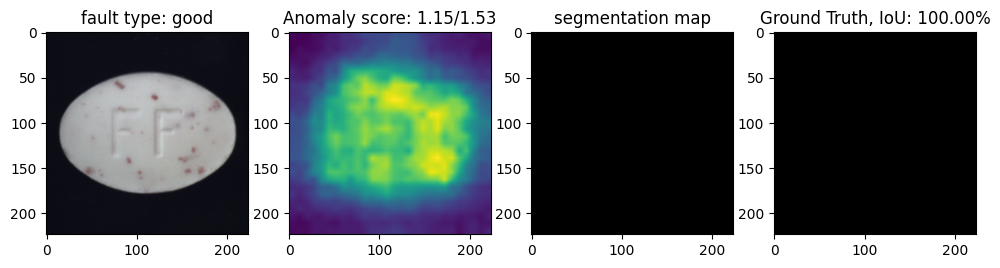

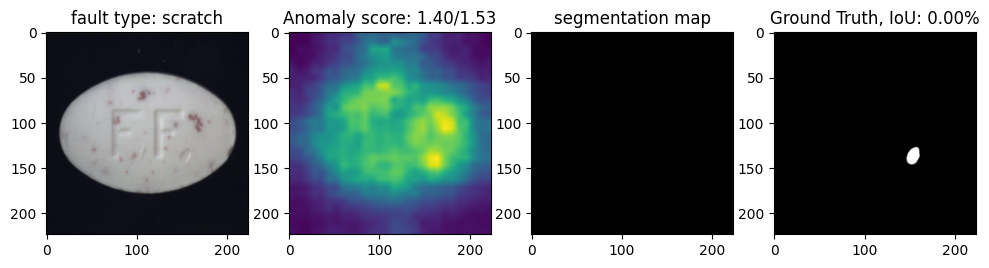

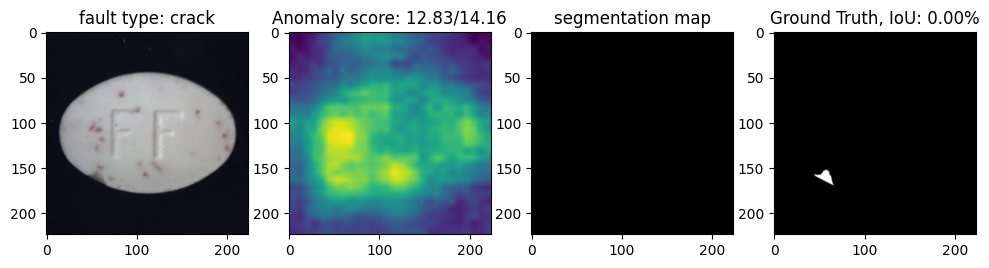

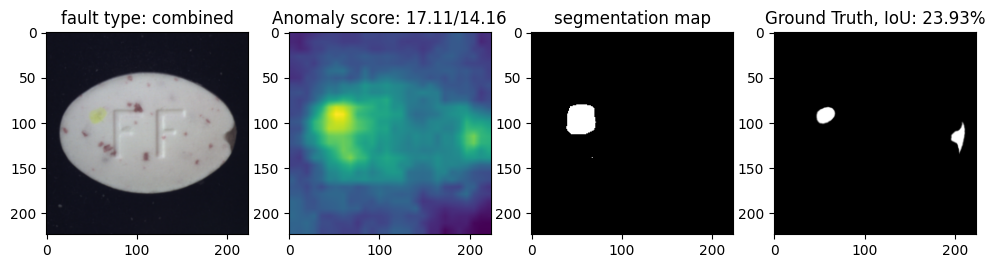

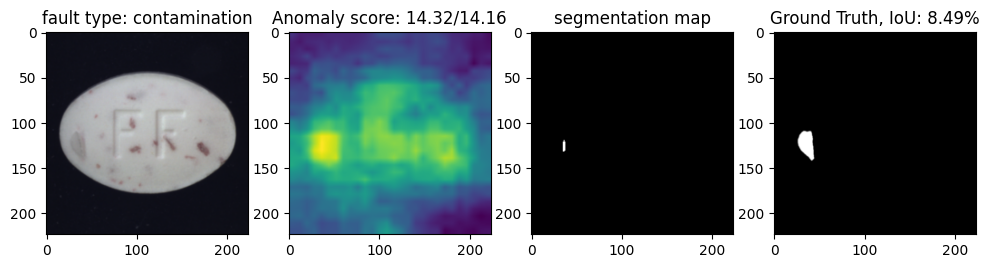

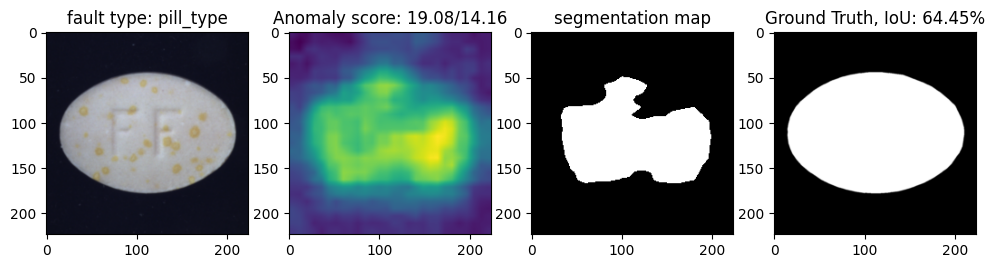

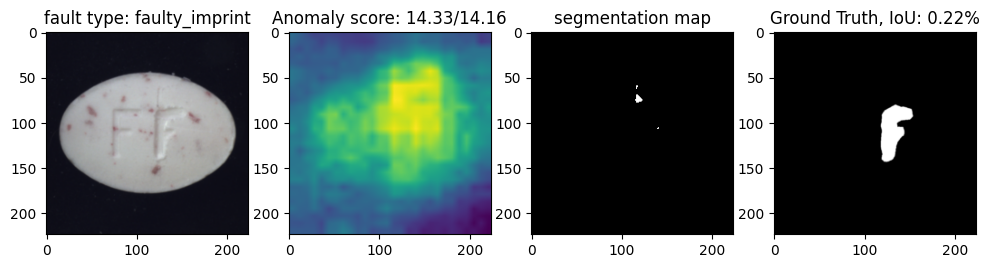

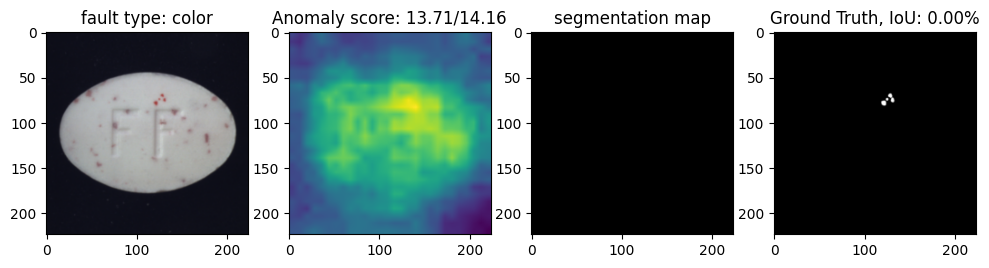

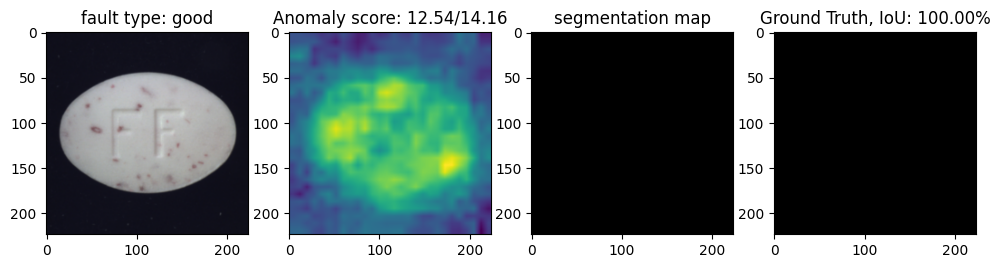

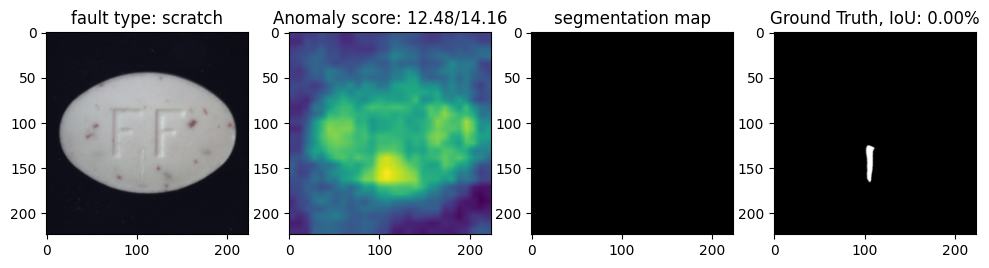

In [14]:
for dataset in datasets:
        for net in nets:
            show_examples(net, dataset)

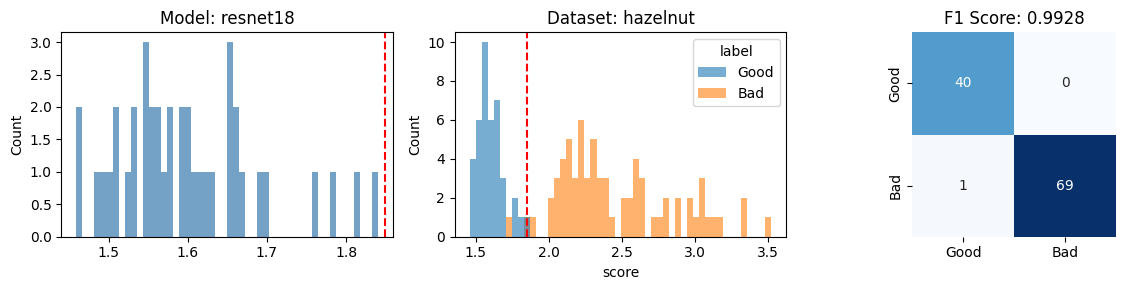

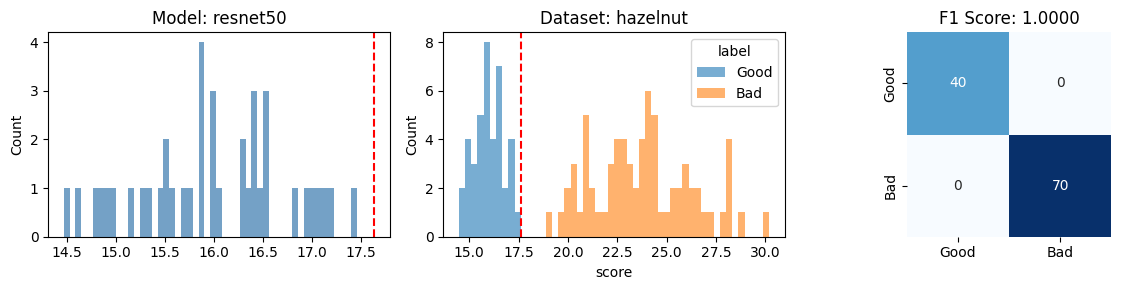

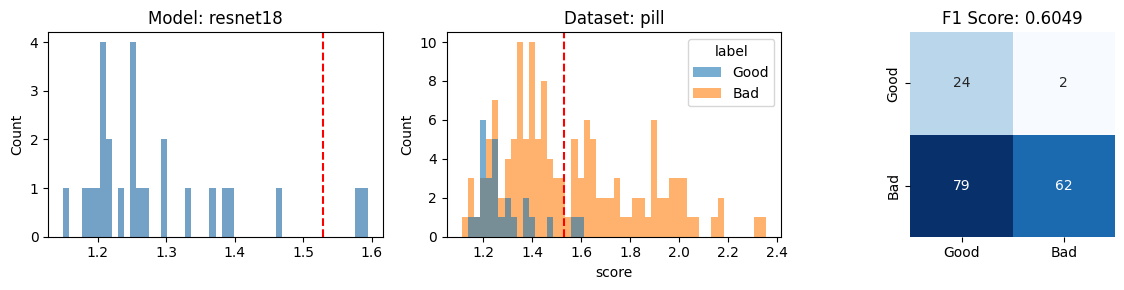

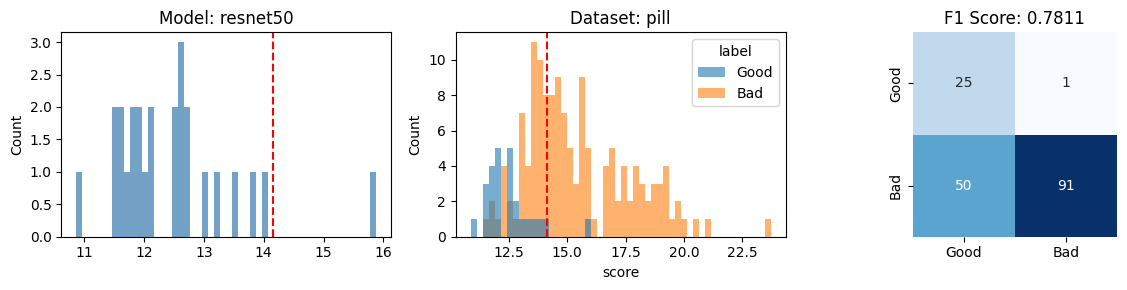

In [15]:
results = pd.DataFrame({
        "Dataset": [],
        "F1 Score": [],
        "Training Time": [],
        "Testing Time": [],
        "Model": []
    }) 
for dataset in datasets:
        for net in nets:
            show_results(net, dataset)
            subresults = pd.DataFrame({
                "Dataset": datasets,
                "F1 Score": [net.f1_scores[dataset] for dataset in datasets],
                "Training Time": [net.training_times[dataset] for dataset in datasets],
                "Testing Time": [net.testing_times[dataset] for dataset in datasets],
                "Model": net.name
            })
            results = pd.concat([results, subresults], ignore_index=True)

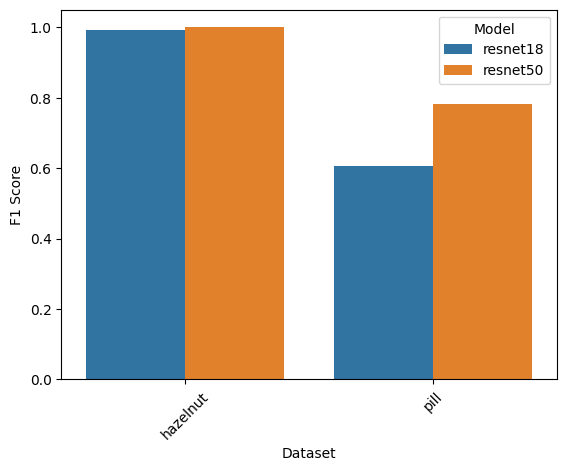

In [16]:
sns.barplot(data=results, x="Dataset", y="F1 Score", hue="Model")
plt.xticks(rotation=45)
plt.show()

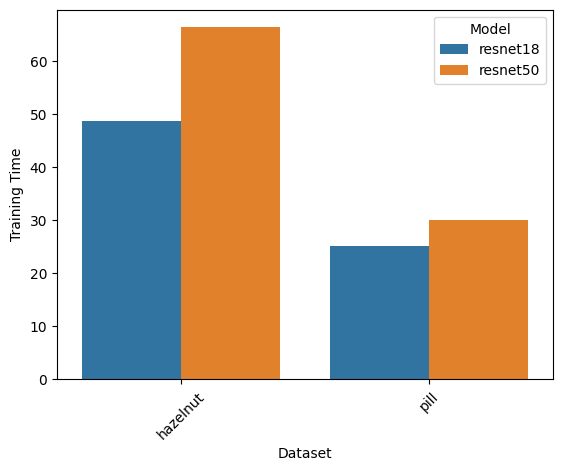

In [17]:
sns.barplot(data=results, x="Dataset", y="Training Time", hue="Model")
plt.xticks(rotation=45)
plt.show()

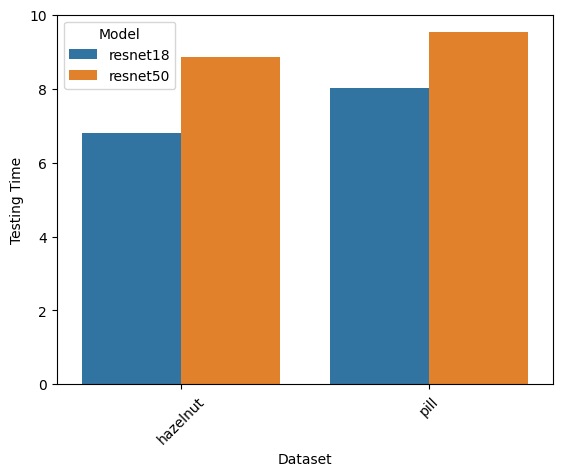

In [18]:
sns.barplot(data=results, x="Dataset", y="Testing Time", hue="Model")
plt.xticks(rotation=45)
plt.show()

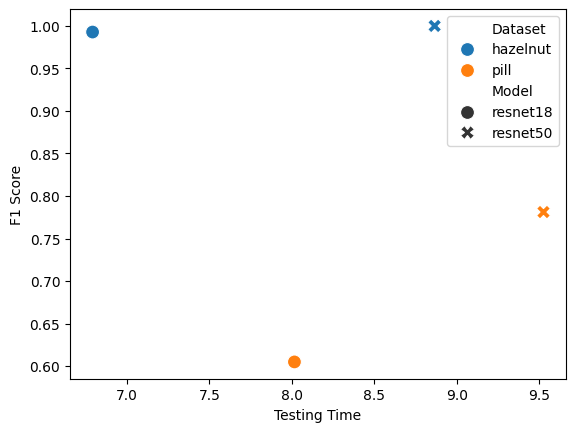

In [19]:
sns.scatterplot(data=results, x="Testing Time", y="F1 Score", hue="Dataset", style="Model", s=100)
plt.show()